In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Helvetica'

import what_where as ww

import seaborn as sns

In [3]:
cfg = ww.utils.load_config("config_contrast_detection")

results_dir = ww.utils.RESULTS_DIR / cfg.experiment.name
results_dir.mkdir(parents=True, exist_ok=True)

figures_dir = ww.utils.get_figures_dir(cfg)

In [4]:
def extract_web_plot_digitizer_dataset(df, col_name):
    idx = df.columns.get_loc(col_name)
    out = df.iloc[1:, [idx, idx+1]].dropna()  # skip row 0
    out.columns = ["x", "y"]
    out = out.astype(float)  # ensure numeric
    return out


In [5]:

results_path = results_dir / f"{cfg.experiment.name}_results_data.parquet"
activations_path = results_dir / f"{cfg.experiment.name}_activations.npy"

In [6]:
df_trials = pd.read_parquet(results_path)
df_trials

,orientation_left,orientation_right,contrast_left,contrast_right,present_left,present_right,attend_left,present_pred,accuracy,gain_suppression,gain_suppression_sampled,stimulus_onset,energy_cost,energy_use,t,repetition,trial
0,1.533468,1.285747,0.000000,0.491130,False,True,False,0.469588,0.0,0.0,0.0,2,-8.0,4551.566895,0,0,0
1,1.037052,3.072904,0.000000,0.000000,False,False,True,0.489477,1.0,0.0,0.0,2,-8.0,4484.688965,0,0,1
2,0.223489,2.437022,0.000000,0.000000,False,False,True,0.488236,1.0,0.0,0.0,2,-8.0,4555.048340,0,0,2
3,2.107387,1.357240,0.000000,0.295260,False,True,False,0.471152,0.0,0.0,0.0,1,-8.0,4607.247559,0,0,3
4,1.991379,0.643127,0.194924,0.014248,True,True,False,0.454351,0.0,0.0,0.0,1,-8.0,4714.752930,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2159995,3.125212,2.094214,0.000000,0.000000,False,False,False,0.191706,1.0,50.0,0.0,2,-6.0,7909.356934,3,2,9995
2159996,1.445857,2.095755,0.424916,0.465276,True,True,True,0.999815,1.0,50.0,0.0,2,-6.0,7947.531250,3,2,9996
2159997,1.350731,2.216475,0.000000,0.247842,False,True,True,0.101128,1.0,50.0,0.0,1,-6.0,7661.933594,3,2,9997
2159998,2.120033,1.165596,0.000000,0.000000,False,False,True,0.262522,1.0,50.0,50.0,1,-6.0,8127.532715,3,2,9998


In [7]:
activations_np = np.load(activations_path, allow_pickle=True).item()

In [8]:

activation_data = {}
trials = df_trials["trial"].values
reps = df_trials["repetition"].values
ts = df_trials["t"].values
energy_cost_cat = pd.Categorical(df_trials["energy_cost"], categories=cfg.experiment.energy_costs)
gain_suppression_cat = pd.Categorical(df_trials["gain_suppression"], categories=cfg.experiment.gain_suppression_amounts)
energy_cost_indices = energy_cost_cat.codes
gain_suppression_indices = gain_suppression_cat.codes


for conv_layer in ["conv1", "conv3"]:
    for side in ["left", "right"]:
        n_channels = 64 if conv_layer == "conv1" else 256
        
        # Extract all activations at once: shape will be (n_rows, n_channels)
        layer_activations = activations_np[conv_layer][side][trials, reps, gain_suppression_indices, energy_cost_indices, ts, :]
        
        # Split into individual channels
        for ch in range(n_channels):
            activation_data[f"{conv_layer}_ch{ch}_activation_{side}"] = layer_activations[:, ch]

df_full = pd.concat([df_trials, pd.DataFrame(activation_data)], axis=1)

<Axes: xlabel='gain_suppression_sampled', ylabel='accuracy'>

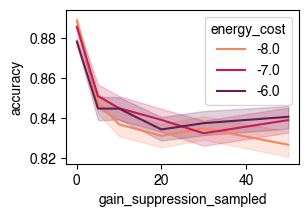

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(3, 2))

energy_costs = df_full["energy_cost"].unique()

sns.lineplot(df_full[df_full["t"] == 3],
            x="gain_suppression_sampled",
            y="accuracy", 
            hue="energy_cost",
            palette=sns.color_palette("rocket_r", n_colors=len(energy_costs)),
            ax=axs)

In [10]:
# energy_cost_selected = cfg.experiment.energy_cost_selected
# gain_suppression_selected = cfg.experiment.gain_suppression_selected
energy_cost_selected = -7.0
gain_suppression_selected = 50.0

BASE_SEL = ((df_full["energy_cost"] == energy_cost_selected) & (df_full["gain_suppression"] == gain_suppression_selected))
df_sel = df_full[BASE_SEL].copy()
df_sel

,orientation_left,orientation_right,contrast_left,contrast_right,present_left,present_right,attend_left,present_pred,accuracy,gain_suppression,...,conv3_ch246_activation_right,conv3_ch247_activation_right,conv3_ch248_activation_right,conv3_ch249_activation_right,conv3_ch250_activation_right,conv3_ch251_activation_right,conv3_ch252_activation_right,conv3_ch253_activation_right,conv3_ch254_activation_right,conv3_ch255_activation_right
8192,1.533468,1.285747,0.000000,0.491130,False,True,False,0.498470,0.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8193,1.037052,3.072904,0.000000,0.000000,False,False,True,0.484326,1.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8194,0.223489,2.437022,0.000000,0.000000,False,False,True,0.491710,1.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8195,2.107387,1.357240,0.000000,0.295260,False,True,False,0.461755,0.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8196,1.991379,0.643127,0.194924,0.014248,True,True,False,0.473278,0.0,50.0,...,0.126085,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2159931,3.125212,2.094214,0.000000,0.000000,False,False,False,0.105431,1.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2159932,1.445857,2.095755,0.424916,0.465276,True,True,True,0.999994,1.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2159933,1.350731,2.216475,0.000000,0.247842,False,True,True,0.205202,1.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2159934,2.120033,1.165596,0.000000,0.000000,False,False,True,0.109265,1.0,50.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:

def add_norm_cols(df):
    norm_cols = {}

    # z-score normalizing per channel (equivalent to per-neuron in biology)
    for col in df.columns:
        if 'activation' in col and 'ch' in col and 'norm' not in col:
            # print(col)
            baseline = df[df["t"] == 0][col].mean()
            if baseline != 0:
                norm_cols[col + '_norm'] = (df[col] - baseline) / baseline
            else:
                print(f"Warning: Baseline for {col} is zero, skipping normalization.")
                norm_cols[col + '_norm'] = df[col]

    norm_df = pd.DataFrame(norm_cols)
    df = pd.concat([df, norm_df], axis=1)

    return df

# df_sel = add_norm_cols(df_sel)

In [12]:
def get_df_attention(df):
    """
    Optimized version using vectorized operations instead of row-by-row iteration.
    Creates two rows per original row, separating by left/right side.
    """

    def get_side_conv_layer_df(df, side, conv_layer):
        activation_cols = [col for col in df.columns if 'activation' in col and side in col and 'norm' not in col and conv_layer in col]
        side_data = {
            'side': side,
            'conv_layer': conv_layer,
            'attention': df['attend_left'] if side == 'left' else ~df['attend_left'],
            'laser': df['gain_suppression_sampled'] > 0.0,
            'present_pred': df['present_pred'], # model prediction whether the grating is present
            'target_report': df['present_pred'] > 0.5,
            'accuracy': df['accuracy'],
            'contrast': df['contrast_left'] if side == 'left' else df['contrast_right'],
            'mean_activation': df[activation_cols].mean(axis=1),
            'trial': df['trial'],
            'repetition': df['repetition'],
            't': df['t'],
            'stimulus_onset': df['stimulus_onset'],
            't_stimulus_onset_aligned': df["stimulus_onset"] - df["t"], # align to stimulus onset
        }
        side_conv_layer_df = pd.DataFrame(side_data)
        return side_conv_layer_df

    # Create DataFrames and concatenate
    side_conv_layer_dfs = []
    for side in ['left', 'right']:
        for conv_layer in ['conv1', 'conv3']:
            side_conv_layer_df = get_side_conv_layer_df(df, side, conv_layer)
            side_conv_layer_dfs.append(side_conv_layer_df)

    result_df = pd.concat(side_conv_layer_dfs, ignore_index=True)

    # adding contrast bins
    contrast_bins = list(np.linspace(0.0, 0.5, 6, dtype=float))
    contrast_bin_labels = ["0", "c1", "c2", "c3", "c4"]
    result_df[f"contrast_bin"] = pd.cut(result_df[f"contrast"], bins=contrast_bins, include_lowest=True, labels=contrast_bin_labels)
    
    return result_df

df = get_df_attention(df_sel)
df

,side,conv_layer,attention,laser,present_pred,target_report,accuracy,contrast,mean_activation,trial,repetition,t,stimulus_onset,t_stimulus_onset_aligned,contrast_bin
0,left,conv1,False,False,0.498470,False,0.0,0.000000,0.002135,0,0,0,2,2,0
1,left,conv1,True,True,0.484326,False,1.0,0.000000,0.001366,1,0,0,2,2,0
2,left,conv1,True,False,0.491710,False,1.0,0.000000,0.003731,2,0,0,2,2,0
3,left,conv1,False,True,0.461755,False,0.0,0.000000,0.005865,3,0,0,1,1,0
4,left,conv1,False,False,0.473278,False,0.0,0.194924,0.003300,4,0,0,1,1,c1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479995,right,conv3,True,True,0.105431,False,1.0,0.000000,0.002632,9995,2,3,2,-1,0
479996,right,conv3,False,False,0.999994,True,1.0,0.465276,0.002886,9996,2,3,2,-1,c4
479997,right,conv3,False,True,0.205202,False,1.0,0.247842,0.001419,9997,2,3,1,-2,c2
479998,right,conv3,False,True,0.109265,False,1.0,0.000000,0.001352,9998,2,3,1,-2,0


In [13]:
df['firing_rate'] = df['mean_activation'] * cfg.experiment.activation_to_spike_rate_scaling + cfg.experiment.spike_rate_baseline

/tmp/ipykernel_747225/3483826234.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = subset.groupby("contrast_bin")["target_report_percent"].mean()


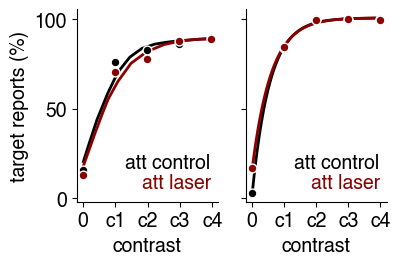

In [14]:
from scipy.optimize import curve_fit

def power_sat(x, rmax, rate, baseline):
    return baseline + rmax * (1 - np.exp(-rate * x))

# behavioral figure
fig, axs = plt.subplots(1, 2, figsize=(4, 2.5), sharey=True)
colors = {"control": "black", "laser": "darkred"}

# --- DATA (left) ---
df_fig1_b = pd.read_csv("debes_fig1_b.csv")
data = {
    key: extract_web_plot_digitizer_dataset(df_fig1_b, key)
    for key in ["att_laser", "att_control", "att_laser_curve", "att_control_curve"]
}
axs[0].plot(data["att_control_curve"]["x"], data["att_control_curve"]["y"], color="black", linewidth=2)
axs[0].scatter(data["att_control"]["x"], data["att_control"]["y"], color="black", edgecolor="white", zorder=5, s=40)
axs[0].plot(data["att_laser_curve"]["x"], data["att_laser_curve"]["y"], color="darkred", linewidth=2)
axs[0].scatter(data["att_laser"]["x"], data["att_laser"]["y"], color="darkred", edgecolor="white", zorder=5, s=40)

# --- MODEL (right) ---
df["target_report_percent"] = df["target_report"].astype(float) * 100.0
model_data = df[(df["t"] == 3) & (df["attention"] == True)]

for laser_val, color in zip([False, True], ["black", "darkred"]):
    subset = model_data[model_data["laser"] == laser_val]
    grouped = subset.groupby("contrast_bin")["target_report_percent"].mean()

    # Map contrast bins to numeric for fitting
    contrast_map = {"0": 0, "c1": 1, "c2": 2, "c3": 3, "c4": 4}
    x_vals = np.array([contrast_map[c] for c in grouped.index])
    y_vals = grouped.values

    # Scatter
    axs[1].scatter(x_vals, y_vals, color=color, edgecolor="white", zorder=5, s=40)

    # Fit curve
    try:
        x_smooth = np.linspace(0, 4, 100)
        popt, _ = curve_fit(power_sat, x_vals, y_vals,
                            p0=[100, 2, 0], maxfev=10000,
                            bounds=([0, 0, -50], [200, 50, 50]))
        axs[1].plot(x_smooth, power_sat(x_smooth, *popt), color=color, linewidth=2)
    except RuntimeError:
        axs[1].plot(x_vals, y_vals, color=color, linewidth=2)

# --- Shared formatting ---
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(["0", "c1", "c2", "c3", "c4"])
    ax.set_xlabel("contrast", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)

axs[0].set_ylabel("target reports (%)", fontsize=14)

# Color-coded legend on both panels
for ax in axs:
    ax.text(0.95, 0.25, "att control", color="black", fontsize=14,
            transform=ax.transAxes, va="top", ha="right")
    ax.text(0.95, 0.15, "att laser", color="darkred", fontsize=14,
            transform=ax.transAxes, va="top", ha="right")

fig.savefig(figures_dir / f"{cfg.experiment.name}_behavioral_results.png", bbox_inches='tight')
fig.savefig(figures_dir / f"{cfg.experiment.name}_behavioral_results.pdf", bbox_inches='tight')

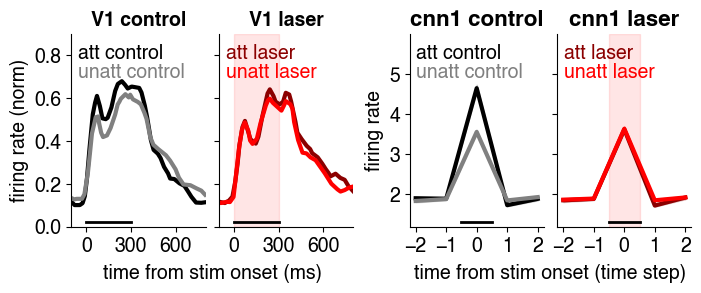

In [15]:
# 2A
# attended vs unattended (no laser (no gain suppression) control)
# attended vs. unattended (laser (gain suppression) control)

import matplotlib.gridspec as gridspec

# fig, axs = plt.subplots(1, 4, figsize=(9, 2.5))
# fig.subplots_adjust(wspace=0.6)

fig = plt.figure(figsize=(8, 2.5))
gs = gridspec.GridSpec(1, 2, wspace=0.2)  # two main groups, wider gap between them

gs_left = gs[0].subgridspec(1, 2, wspace=0.1)   # V1 panels, tight
gs_right = gs[1].subgridspec(1, 2, wspace=0.1)   # model panels, tight

axs = [
    fig.add_subplot(gs_left[0]),
    fig.add_subplot(gs_left[1]),
    fig.add_subplot(gs_right[0]),
    fig.add_subplot(gs_right[1]),
]

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# axs[1].sharey(axs[0])
# axs[3].sharey(axs[2])

for add in [0, 2]:
    axs[0+add].text(0.05, 0.95, "att control", color="black", fontsize=14, transform=axs[0+add].transAxes, va="top")
    axs[0+add].text(0.05, 0.85, "unatt control", color="gray", fontsize=14, transform=axs[0+add].transAxes, va="top")
    axs[1+add].text(0.05, 0.95, "att laser", color="darkred", fontsize=14, transform=axs[1+add].transAxes, va="top")
    axs[1+add].text(0.05, 0.85, "unatt laser", color="red", fontsize=14, transform=axs[1+add].transAxes, va="top")

axs[0].plot([0, 300], [0.02, 0.02], color="black", linewidth=2, clip_on=False)
axs[1].plot([0, 300], [0.02, 0.02], color="black", linewidth=2, clip_on=False)

axs[2].plot([-0.5, 0.5], [1.3, 1.3], color="black", linewidth=2, clip_on=False)
axs[3].plot([-0.5, 0.5], [1.3, 1.3], color="black", linewidth=2, clip_on=False)

# data
df_fig2_a_1 = pd.read_csv("debes_fig2_a_1.csv")
data = {
    key: extract_web_plot_digitizer_dataset(df_fig2_a_1, key)
    for key in ["att_control", "unatt_control"]
}
axs[0].plot(data["att_control"]["x"], data["att_control"]["y"], color="black", label="Att control", linewidth=3)
axs[0].plot(data["unatt_control"]["x"], data["unatt_control"]["y"], color="gray", label="Unatt control", linewidth=3)


df_fig2_a_2 = pd.read_csv("debes_fig2_a_2.csv")
data = {
    key: extract_web_plot_digitizer_dataset(df_fig2_a_2, key)
    for key in ["att_laser", "unatt_laser"]
}
axs[1].plot(data["att_laser"]["x"], data["att_laser"]["y"], color="darkred", label="Att laser", linewidth=3)
axs[1].plot(data["unatt_laser"]["x"], data["unatt_laser"]["y"], color="red", label="Unatt laser", linewidth=3)


for i in range(2):
    axs[i].set_xlim(-100, 800)
    axs[i].set_xticks([0, 300, 600])
    axs[i].set_ylim(0.0, 0.9)
    axs[i].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
    axs[i].set_ylabel("firing rate (norm)", fontsize=14)
    axs[i].set_xlabel("time from stim\nonset (ms)", fontsize=14)
axs[1].axvspan(0, 300, color="red", alpha=0.1, label="Laser (gain suppression)")


axs[0].set_title("V1 control", fontweight="bold", fontsize=14)
axs[1].set_title("V1 laser", fontweight="bold", fontsize=14)

axs[1].set_ylabel("")
axs[1].set_yticklabels([])

# model
axs = axs[2:]

contrast = "c4"
conv_layer = "conv1"

for (i, laser) in enumerate([False, True]):
    palette = ["red", "darkred"] if laser else ["gray", "black"]
    for attention in [True, False]:
        color = palette[attention]

        sel = (df["laser"] == laser)
        sel &= (df["contrast_bin"] == contrast)
        sel &= (df["attention"] == attention) 
        sel &= (df["conv_layer"] == conv_layer)

        label = "Att " if attention else "Unatt "
        label += "laser" if laser else "control"

        sns.lineplot(df[sel],
                    x="t_stimulus_onset_aligned",
                    y="firing_rate",
                    color=color,
                    ax=axs[i],
                    label=label,
                    linewidth=3)
        
    axs[i].legend_.remove()

    axs[i].set_xlabel("time from stim\nonset (time step)", fontsize=14)
    axs[i].set_ylabel("firing rate", fontsize=14)
    axs[i].set_ylim(1.2, 6.0)
    axs[i].set_yticks([2, 3, 4, 5])
    axs[i].set_xticks([-2, -1, 0, 1, 2])

        
axs[1].axvspan(-0.5, 0.5, color="red", alpha=0.1, label="Laser (gain suppression)")

axs[0].set_title("cnn1 control", fontweight="bold", fontsize=16)
axs[1].set_title("cnn1 laser", fontweight="bold", fontsize=16)
axs[1].set_ylabel("")
axs[1].set_yticklabels([])

# Remove individual x-labels (replace your existing set_xlabel lines with "")
for ax in fig.axes:
    ax.set_xlabel("")

# Add centered labels under each pair after plotting
left_center = (fig.axes[0].get_position().x0 + fig.axes[1].get_position().x1) / 2
right_center = (fig.axes[2].get_position().x0 + fig.axes[3].get_position().x1) / 2

fig.text(left_center, -0.1, "time from stim onset (ms)", ha="center", fontsize=14)
fig.text(right_center, -0.1, "time from stim onset (time step)", ha="center", fontsize=14)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=14)

fig.savefig(figures_dir / f"{cfg.experiment.name}_neural_results_V1.png", bbox_inches='tight')
fig.savefig(figures_dir / f"{cfg.experiment.name}_neural_results_V1.pdf", bbox_inches='tight')

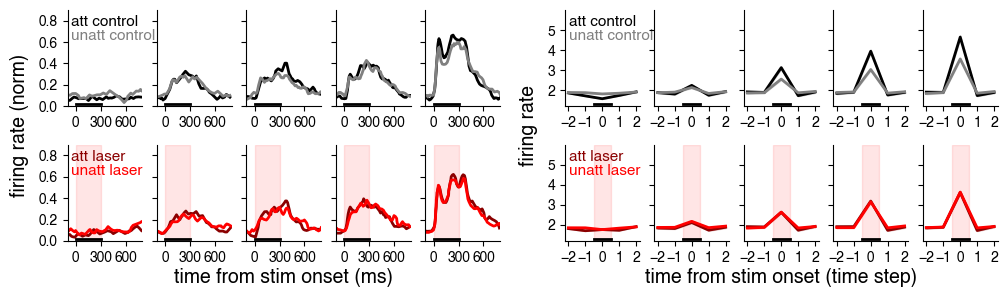

In [16]:
# 2B
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 3.0))

# Two main groups: data (left) and model (right)
gs = gridspec.GridSpec(1, 2, wspace=0.15)
gs_left = gs[0].subgridspec(2, 5, wspace=0.2, hspace=0.4)
gs_right = gs[1].subgridspec(2, 5, wspace=0.2, hspace=0.4)

axs_data = np.array([[fig.add_subplot(gs_left[row, col]) for col in range(5)] for row in range(2)])
axs_model = np.array([[fig.add_subplot(gs_right[row, col]) for col in range(5)] for row in range(2)])

for ax in np.concatenate([axs_data.flatten(), axs_model.flatten()]):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- DATA (left) ---
for row, laser_suffix in enumerate(["control", "laser"]):
# for row, laser_suffix in enumerate(["control"]):
    palette = ["gray", "black"] if row == 0 else ["red", "darkred"]
    keys = [f"att_{laser_suffix}", f"unatt_{laser_suffix}"]

    for col in range(5):
        ax = axs_data[row, col]
        df_panel = pd.read_csv(f"debes_fig2_b_{row+1}_{col+1}.csv")
        data = {
            key: extract_web_plot_digitizer_dataset(df_panel, key)
            for key in keys
        }
        ax.plot(data[f"att_{laser_suffix}"]["x"], data[f"att_{laser_suffix}"]["y"],
                color=palette[1], linewidth=2)
        ax.plot(data[f"unatt_{laser_suffix}"]["x"], data[f"unatt_{laser_suffix}"]["y"],
                color=palette[0], linewidth=2)

        ax.set_xlim(-100, 800)
        ax.set_xticks([0, 300, 600])
        ax.set_ylim(0.0, 0.9)
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
        ax.plot([0, 300], [0.02, 0.02], color="black", linewidth=2, clip_on=False)
        ax.set_xlabel("")
        ax.set_ylabel("")

        if row == 1:
            ax.axvspan(0, 300, color="red", alpha=0.1)

        if col > 0:
            ax.set_yticklabels([])

    # Legend on first column only
    axs_data[row, 0].text(0.05, 0.95, f"att {laser_suffix}", color=palette[1], fontsize=11,
                           transform=axs_data[row, 0].transAxes, va="top")
    axs_data[row, 0].text(0.05, 0.80, f"unatt {laser_suffix}", color=palette[0], fontsize=11,
                           transform=axs_data[row, 0].transAxes, va="top")

axs_data[0, 0].set_ylabel("firing rate (norm)", fontsize=14)
axs_data[1, 0].set_ylabel("firing rate (norm)", fontsize=14)

# --- MODEL (right) ---
contrasts = ["0", "c1", "c2", "c3", "c4"]
conv_layer = "conv1"

for row, laser in enumerate([False, True]):
    palette = ["gray", "black"] if not laser else ["red", "darkred"]

    for col, contrast in enumerate(contrasts):
        ax = axs_model[row, col]
        for attention in [True, False]:
            color = palette[attention]
            sel = (df["laser"] == laser)
            sel &= (df["contrast_bin"] == contrast)
            sel &= (df["attention"] == attention)
            sel &= (df["conv_layer"] == conv_layer)

            sns.lineplot(df[sel],
                         x="t_stimulus_onset_aligned",
                         y="firing_rate",
                         color=color,
                         ax=ax,
                         linewidth=2)

        if hasattr(ax, 'legend_') and ax.legend_ is not None:
            ax.legend_.remove()

        ax.set_ylim(1.2, 6.0)
        ax.set_yticks([2, 3, 4, 5])
        ax.set_xticks([-2, -1, 0, 1, 2])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.plot([-0.5, 0.5], [1.3, 1.3], color="black", linewidth=2, clip_on=False)


        if laser:
            ax.axvspan(-0.5, 0.5, color="red", alpha=0.1)

        if col > 0:
            ax.set_yticklabels([])

    # Legend on first column only
    label_laser = "laser" if laser else "control"
    axs_model[row, 0].text(0.05, 0.95, f"att {label_laser}", color=palette[1], fontsize=11,
                            transform=axs_model[row, 0].transAxes, va="top")
    axs_model[row, 0].text(0.05, 0.80, f"unatt {label_laser}", color=palette[0], fontsize=11,
                            transform=axs_model[row, 0].transAxes, va="top")

axs_model[0, 0].set_ylabel("firing rate", fontsize=14)
axs_model[1, 0].set_ylabel("firing rate", fontsize=14)

# Centered x-labels under each group
left_center = (axs_data[1, 0].get_position().x0 + axs_data[1, 4].get_position().x1) / 2
right_center = (axs_model[1, 0].get_position().x0 + axs_model[1, 4].get_position().x1) / 2

fig.text(left_center, -0.03, "time from stim onset (ms)", ha="center", fontsize=14)
fig.text(right_center, -0.03, "time from stim onset (time step)", ha="center", fontsize=14)

for ax in np.concatenate([axs_data.flatten(), axs_model.flatten()]):
    ax.tick_params(axis="both", labelsize=10)

# Remove individual y-labels
axs_data[0, 0].set_ylabel("")
axs_data[1, 0].set_ylabel("")
axs_model[0, 0].set_ylabel("")
axs_model[1, 0].set_ylabel("")

# Centered y-labels for each group
data_top = axs_data[0, 0].get_position().y1
data_bottom = axs_data[1, 0].get_position().y0
data_left = axs_data[0, 0].get_position().x0

model_top = axs_model[0, 0].get_position().y1
model_bottom = axs_model[1, 0].get_position().y0
model_left = axs_model[0, 0].get_position().x0

fig.text(data_left - 0.04, (data_top + data_bottom) / 2,
         "firing rate (norm)", ha="center", va="center", rotation="vertical", fontsize=14)
fig.text(model_left - 0.03, (model_top + model_bottom) / 2,
         "firing rate", ha="center", va="center", rotation="vertical", fontsize=14)

fig.savefig(figures_dir / f"{cfg.experiment.name}_neural_results_V1_by_contrast.png", bbox_inches='tight')
fig.savefig(figures_dir / f"{cfg.experiment.name}_neural_results_V1_by_contrast.pdf", bbox_inches='tight')

Text(0.5, 1.0, 'cnn1 laser (V1)\n(gain suppression)')

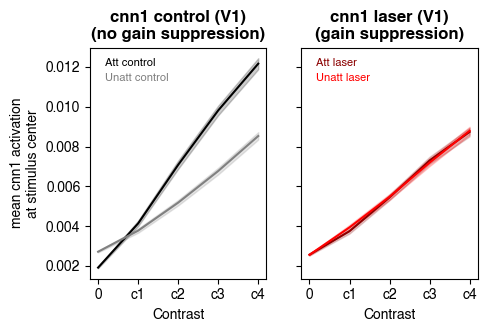

In [17]:
# 2C

fig, axs = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

conv_layer = "conv1"

for (i, laser) in enumerate([False, True]):
    palette = ["red", "darkred"] if laser else ["gray", "black"]
    for attention in [True, False]:
        color = palette[attention]

        sel = (df["laser"] == laser)
        # sel &= (df["contrast_bin"] == contrast)
        sel &= (df["attention"] == attention) 
        sel &= (df["conv_layer"] == conv_layer)
        sel &= (df["t_stimulus_onset_aligned"] == 0)  # only show the stimulus pass

        label = "Att " if attention else "Unatt "
        label += "laser" if laser else "control"

        sns.lineplot(df[sel],
                    x="contrast_bin",
                    y="mean_activation",
                    color=color,
                    ax=axs[i],
                    label=label)
        
    legend = axs[i].legend(loc="upper left", fontsize=8, frameon=False, bbox_to_anchor=(-0.15, 1.0))

    # Hide all legend lines/markers
    for handle in legend.legend_handles:
        handle.set_visible(False)

    # Color the text
    for text in legend.get_texts():
        if 'Unatt' in text.get_text():
            text.set_color(palette[0])
        else:  # 'Att' in text
            text.set_color(palette[1])


    axs[i].set_xlabel("Contrast")
    axs[i].set_ylabel("mean cnn1 activation\nat stimulus center")

        

axs[0].set_title("cnn1 control (V1)\n(no gain suppression)", fontweight="bold")
axs[1].set_title("cnn1 laser (V1)\n(gain suppression)", fontweight="bold")



Text(0.5, 1.0, 'cnn3 laser (V1)\n(gain suppression)')

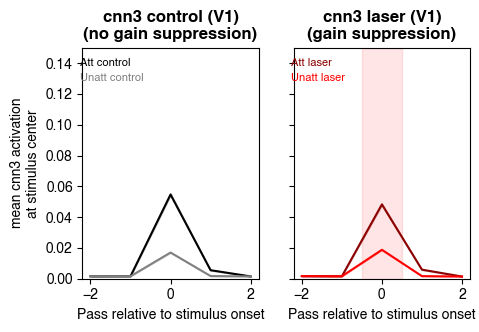

In [18]:
# 4D
# attended vs unattended (no laser (no gain suppression) control)
# attended vs. unattended (laser (gain suppression) control)

fig, axs = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

contrast = "c4"
conv_layer = "conv3"

for (i, laser) in enumerate([False, True]):
    palette = ["red", "darkred"] if laser else ["gray", "black"]
    for attention in [True, False]:
        color = palette[attention]

        sel = (df["laser"] == laser)
        sel &= (df["contrast_bin"] == contrast)
        sel &= (df["attention"] == attention) 
        sel &= (df["conv_layer"] == conv_layer)

        label = "Att " if attention else "Unatt "
        label += "laser" if laser else "control"

        sns.lineplot(df[sel],
                    x="t_stimulus_onset_aligned",
                    y="mean_activation",
                    color=color,
                    ax=axs[i],
                    label=label)
        
    legend = axs[i].legend(loc="upper left", fontsize=8, frameon=False, bbox_to_anchor=(-0.25, 1.0))

    # Hide all legend lines/markers
    for handle in legend.legend_handles:
        handle.set_visible(False)

    # Color the text
    for text in legend.get_texts():
        if 'Unatt' in text.get_text():
            text.set_color(palette[0])
        else:  # 'Att' in text
            text.set_color(palette[1])


    axs[i].set_xlabel("Pass relative to stimulus onset")
    axs[i].set_ylabel("mean cnn3 activation\nat stimulus center")
    axs[i].set_ylim(0.0, 0.15)

        
axs[1].axvspan(-0.5, 0.5, color="red", alpha=0.1, label="Laser (gain suppression)")

axs[0].set_title("cnn3 control (V1)\n(no gain suppression)", fontweight="bold")
axs[1].set_title("cnn3 laser (V1)\n(gain suppression)", fontweight="bold")